# SIREN: Implicit Neural Representations with Periodic Activation Functions
## Poisson & SDF Experiments
**Paper:** Sitzmann et al., NeurIPS 2020  
**Repo:** https://github.com/vsitzmann/siren

---
## Setup: Clone Repo & Install Dependencies

In [1]:
# Clone the official SIREN repo
!git clone https://github.com/vsitzmann/siren.git

# Install all required packages
!pip install sk-video cmapy configargparse einops scikit-image trimesh matplotlib numpy scipy tqdm imageio

import torch
print('PyTorch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Cloning into 'siren'...
remote: Enumerating objects: 193, done.
remote: Total 193 (delta 0), reused 0 (delta 0), pack-reused 193 (from 1)
Receiving objects: 100% (193/193), 2.17 MiB | 18.71 MiB/s, done.
Resolving deltas: 100% (70/70), done.
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.8/740.8 kB 39.6 MB/s eta 0:00:00
  Created wheel for cmapy: filename=cmapy-0.6.6-py3-none-any.whl size=3938 sha256=5e0d43486d995f754065f582246f474812e720fbcaf8fb22fcf616776b86408b
  Stored in directory: /root/.cache/pip/wheels/8f/8b/45/9402d586dc9795ca029a77c5c8b9f5e3e16b38e7c682883f34
Successfully built cmapy
PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


---
##  Imports

In [2]:
import sys
import os
import re
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.utils.data import DataLoader
from skimage import measure
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import trimesh

# Add siren to path so we can import its modules
sys.path.append('/content/siren')
import dataio, modules, utils, training, loss_functions

# Output directory for all saved figures
os.makedirs('/content/siren/results', exist_ok=True)
os.makedirs('/content/siren/logs',    exist_ok=True)

print('All imports successful!')

All imports successful!


/content/siren/training.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


---
# PART 1 — POISSON EXPERIMENTS
Reconstruct an image supervised ONLY on its gradients or Laplacian — never seeing pixel values directly.

## Train: Poisson Gradient Experiment

In [12]:
!python /content/siren/experiment_scripts/train_poisson_grad_img.py \
    --experiment_name poisson_gradients \
    --dataset camera \
    --logging_root /content/siren/logs \
    --num_epochs 10000 \
    --batch_size 16384 \
    --lr 1e-4 \
    --steps_til_summary 500 \
    --epochs_til_ckpt 25

2026-04-19 08:52:29.994064: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776588750.015922   25806 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776588750.023177   25806 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776588750.045013   25806 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776588750.045065   25806 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776588750.045071   25806 computation_placer.cc:177] computation placer alr

## Train: Poisson Laplacian Experiment

In [4]:
!python /content/siren/experiment_scripts/train_poisson_lapl_img.py \
    --experiment_name poisson_laplacian \
    --dataset camera \
    --logging_root /content/siren/logs \
    --num_epochs 10000 \
    --batch_size 16384 \
    --lr 1e-4 \
    --steps_til_summary 500 \
    --epochs_til_ckpt 25

2026-04-19 07:49:46.610123: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776584986.646265   10105 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776584986.658298   10105 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776584986.686932   10105 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776584986.686973   10105 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776584986.686981   10105 computation_placer.cc:177] computation placer alr

## Load Loss Files and Compute Loss Curves

In [25]:
import os
import re
import numpy as np

def load_losses(experiment_name):
    ckpt_dir = f'/content/siren/logs/{experiment_name}/checkpoints'

    loss_files = sorted([
        f for f in os.listdir(ckpt_dir)
        if f.startswith('train_losses_epoch') and f.endswith('.txt')
    ])

    epochs, losses = [], []

    for fname in loss_files:
        match = re.search(r'epoch_(\d+)', fname)
        if match is None:
            continue

        epoch = int(match.group(1))
        fpath = os.path.join(ckpt_dir, fname)

        try:
            with open(fpath) as f:
                lines = [l.strip() for l in f.readlines() if l.strip()]
            # Each line is a loss value — take the LAST one (end of that epoch)
            loss_val = float(lines[-1])
            epochs.append(epoch)
            losses.append(loss_val)
        except Exception as e:
            print(f"Skipping {fname}: {e}")

    return np.array(epochs), np.array(losses)


# Load both experiments
epochs_g, losses_g = load_losses('poisson_gradients')
epochs_l, losses_l = load_losses('poisson_laplacian')

print(f"Gradient  — epochs loaded: {len(epochs_g)}, final loss: {losses_g[-1]:.4f}")
print(f"Laplacian — epochs loaded: {len(epochs_l)}, final loss: {losses_l[-1]:.4f}")

Gradient  — epochs loaded: 399, final loss: 0.2330
Laplacian — epochs loaded: 399, final loss: 1836.9658


## Load Trained Models and Run Inference

In [26]:
def get_latest_checkpoint(experiment_name):
    """Returns path of latest saved .pth checkpoint."""
    ckpt_dir = f'/content/siren/logs/{experiment_name}/checkpoints'
    # Prefer model_final if it exists
    final = os.path.join(ckpt_dir, 'model_final.pth')
    if os.path.exists(final):
        return final
    # Otherwise get highest epoch number
    pth_files = sorted([
        f for f in os.listdir(ckpt_dir)
        if f.startswith('model_epoch') and f.endswith('.pth')
    ])
    return os.path.join(ckpt_dir, pth_files[-1])


def load_model(experiment_name):
    """Load SIREN SingleBVPNet from latest checkpoint."""
    ckpt_path = get_latest_checkpoint(experiment_name)
    print(f'Loading checkpoint: {ckpt_path}')
    model = modules.SingleBVPNet(type='sine', mode='mlp', sidelength=(256, 256))
    model.cuda()
    state = torch.load(ckpt_path)
    model.load_state_dict(state)
    model.eval()
    return model


def run_inference(model, coord_dataset):
    """
    Run model inference and return:
      pred_img  — reconstructed image  [256, 256]
      pred_grad — predicted gradients  [256, 256, 2]  (via autograd on model_in)
      gt_img    — ground truth image   [256, 256]
      gt_dict   — full ground truth dict
    """
    model_input, gt = coord_dataset[0]

    # Only pass tensor values to GPU
    coords = model_input['coords'].cuda().unsqueeze(0)  # [1, 65536, 2]

    with torch.no_grad():
        model_output = model({'coords': coords})

    pred_img = model_output['model_out'].squeeze().cpu().numpy().reshape(256, 256)

    # Compute predicted gradients using model_in (the coords the model actually used)
    model_in = model_output['model_in']   # model stores the coords it processed
    model_in.retain_grad()

    # Re-run with grad enabled
    coords_g = model_input['coords'].cuda().unsqueeze(0)
    coords_g.requires_grad_(True)
    out_g = model({'coords': coords_g})
    pred_out_g = out_g['model_out']      # [1, 65536, 1]
    model_in_g  = out_g['model_in']      # [1, 65536, 2]

    grad = torch.autograd.grad(
        outputs=pred_out_g,
        inputs=model_in_g,
        grad_outputs=torch.ones_like(pred_out_g),
        create_graph=False,
        retain_graph=False,
        allow_unused=True
    )[0]

    if grad is not None:
        pred_grad = grad.squeeze().detach().cpu().numpy().reshape(256, 256, 2)
    else:
        # Fallback: finite differences
        print('Autograd returned None — using finite differences for gradients')
        pred_grad = np.stack(np.gradient(pred_img), axis=-1)

    gt_img  = gt['img'].numpy().reshape(256, 256)
    return pred_img, pred_grad, gt_img, gt


# ── Gradient experiment ───────────────────────────────────────────────────────
img_dataset_g  = dataio.Camera()
coord_dataset_g = dataio.Implicit2DWrapper(
    img_dataset_g, sidelength=256, compute_diff='gradients'
)
model_g = load_model('poisson_gradients')
pred_img_g, pred_grad_g, gt_img_g, gt_g = run_inference(model_g, coord_dataset_g)
gt_grad_g = gt_g['gradients'].numpy().reshape(256, 256, 2)
print('Gradient experiment — inference done')

# ── Laplacian experiment ──────────────────────────────────────────────────────
img_dataset_l  = dataio.Camera()
coord_dataset_l = dataio.Implicit2DWrapper(
    img_dataset_l, sidelength=256, compute_diff='laplacian'
)
model_l = load_model('poisson_laplacian')
pred_img_l, pred_grad_l, gt_img_l, gt_l = run_inference(model_l, coord_dataset_l)
print('Laplacian experiment — inference done')

Loading checkpoint: /content/siren/logs/poisson_gradients/checkpoints/model_final.pth
SingleBVPNet(
  (image_downsampling): ImageDownsampling()
  (net): FCBlock(
    (net): MetaSequential(
      (0): MetaSequential(
        (0): BatchLinear(in_features=2, out_features=256, bias=True)
        (1): Sine()
      )
      (1): MetaSequential(
        (0): BatchLinear(in_features=256, out_features=256, bias=True)
        (1): Sine()
      )
      (2): MetaSequential(
        (0): BatchLinear(in_features=256, out_features=256, bias=True)
        (1): Sine()
      )
      (3): MetaSequential(
        (0): BatchLinear(in_features=256, out_features=256, bias=True)
        (1): Sine()
      )
      (4): MetaSequential(
        (0): BatchLinear(in_features=256, out_features=1, bias=True)
      )
    )
  )
)
Gradient experiment — inference done
Loading checkpoint: /content/siren/logs/poisson_laplacian/checkpoints/model_final.pth
SingleBVPNet(
  (image_downsampling): ImageDownsampling()
  (net): FCB

## Compute Metrics (PSNR) as in Paper

In [27]:
def normalize(img):
    """Normalize image to [0, 1]."""
    mn, mx = img.min(), img.max()
    return (img - mn) / (mx - mn + 1e-8)


def compute_psnr(gt, pred, max_val=1.0):
    """
    Peak Signal-to-Noise Ratio.
    PSNR = 10 * log10(MAX^2 / MSE)
    Higher is better. Paper reports ~32 dB for gradient supervision.
    """
    gt_n   = normalize(gt)
    pred_n = normalize(pred)
    mse = np.mean((gt_n - pred_n) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10(max_val ** 2 / mse)


def compute_mse(gt, pred):
    """Mean Squared Error."""
    return np.mean((normalize(gt) - normalize(pred)) ** 2)


# Metrics for gradient experiment
psnr_g = compute_psnr(gt_img_g, pred_img_g)
mse_g  = compute_mse(gt_img_g,  pred_img_g)

# Metrics for laplacian experiment
psnr_l = compute_psnr(gt_img_l, pred_img_l)
mse_l  = compute_mse(gt_img_l,  pred_img_l)

print('=' * 50)
print('POISSON RECONSTRUCTION METRICS')
print('=' * 50)
print(f'Gradient  supervision — PSNR: {psnr_g:.2f} dB  |  MSE: {mse_g:.6f}')
print(f'Laplacian supervision — PSNR: {psnr_l:.2f} dB  |  MSE: {mse_l:.6f}')
print('(Paper reports ~32.91 dB for gradient supervision)')

POISSON RECONSTRUCTION METRICS
Gradient  supervision — PSNR: 33.56 dB  |  MSE: 0.000440
Laplacian supervision — PSNR: 11.87 dB  |  MSE: 0.064949
(Paper reports ~32.91 dB for gradient supervision)


## VISUALIZATION: Poisson Results

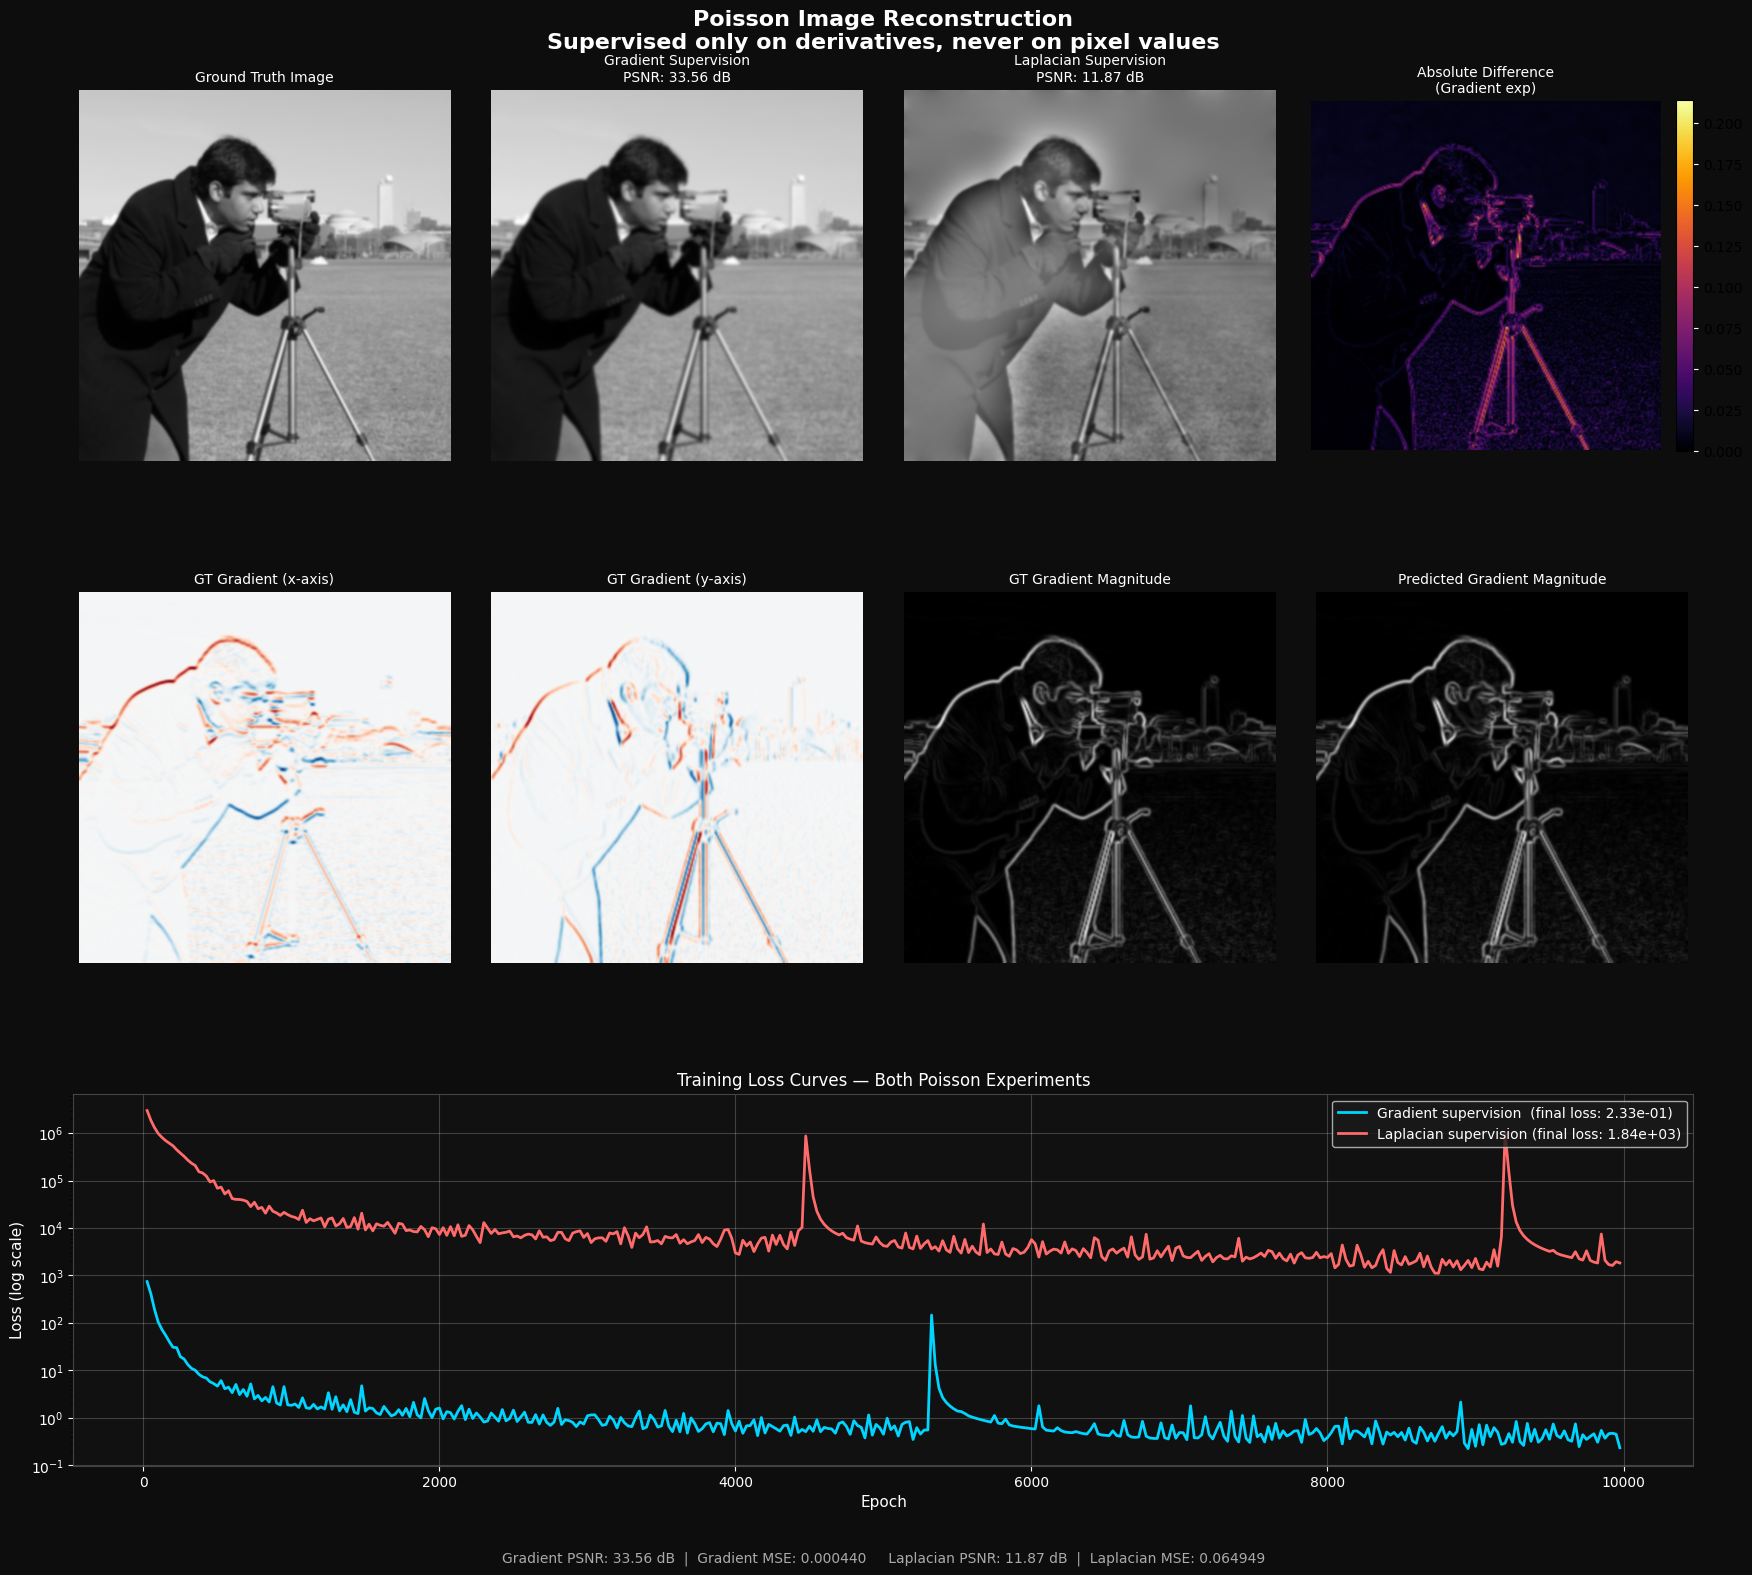

Saved → /content/siren/results/poisson_results.png


In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure layout mirrors Paper Figure 3:
#   Row 1 → Ground truth image | Gradient fitting | Laplacian fitting
#   Row 2 → GT gradients       | Pred gradients (grad exp) | Difference
#   Row 3 → Loss curves (both experiments)
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(18, 16), facecolor='#0d0d0d')
fig.suptitle(
    'Poisson Image Reconstruction\n'
    'Supervised only on derivatives, never on pixel values',
    fontsize=16, color='white', fontweight='bold', y=0.98
)

gs = gridspec.GridSpec(
    3, 4,
    figure=fig,
    hspace=0.35,
    wspace=0.08,
    left=0.05, right=0.95,
    top=0.93, bottom=0.07
)

def dark_ax(ax, title):
    ax.set_facecolor('#0d0d0d')
    ax.set_title(title, color='white', fontsize=10, pad=6)
    ax.axis('off')
    return ax

# ── ROW 1: Images ──────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
ax.imshow(normalize(gt_img_g), cmap='gray', interpolation='bicubic')
dark_ax(ax, 'Ground Truth Image')

ax = fig.add_subplot(gs[0, 1])
ax.imshow(normalize(pred_img_g), cmap='gray', interpolation='bicubic')
dark_ax(ax, f'Gradient Supervision\nPSNR: {psnr_g:.2f} dB')

ax = fig.add_subplot(gs[0, 2])
ax.imshow(normalize(pred_img_l), cmap='gray', interpolation='bicubic')
dark_ax(ax, f'Laplacian Supervision\nPSNR: {psnr_l:.2f} dB')

ax = fig.add_subplot(gs[0, 3])
diff = np.abs(normalize(gt_img_g) - normalize(pred_img_g))
im = ax.imshow(diff, cmap='inferno', interpolation='bicubic')
dark_ax(ax, f'Absolute Difference\n(Gradient exp)')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.yaxis.set_tick_params(color='white')

# ── ROW 2: Gradients ───────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
ax.imshow(gt_grad_g[:, :, 0], cmap='RdBu', interpolation='bicubic')
dark_ax(ax, 'GT Gradient (x-axis)')

ax = fig.add_subplot(gs[1, 1])
ax.imshow(gt_grad_g[:, :, 1], cmap='RdBu', interpolation='bicubic')
dark_ax(ax, 'GT Gradient (y-axis)')

ax = fig.add_subplot(gs[1, 2])
grad_mag_gt = np.sqrt(gt_grad_g[:,:,0]**2 + gt_grad_g[:,:,1]**2)
ax.imshow(grad_mag_gt, cmap='gray', interpolation='bicubic')
dark_ax(ax, 'GT Gradient Magnitude')

ax = fig.add_subplot(gs[1, 3])
if pred_grad_g.ndim == 3:
    grad_mag_pred = np.sqrt(pred_grad_g[:,:,0]**2 + pred_grad_g[:,:,1]**2)
else:
    grad_mag_pred = np.abs(pred_grad_g)
ax.imshow(grad_mag_pred, cmap='gray', interpolation='bicubic')
dark_ax(ax, 'Predicted Gradient Magnitude')

# ── ROW 3: Loss Curves ────────────────────────────────────────────────────
ax_loss = fig.add_subplot(gs[2, :])
ax_loss.set_facecolor('#111111')

ax_loss.semilogy(epochs_g, losses_g, color='#00d4ff', linewidth=2,
                 label=f'Gradient supervision  (final loss: {losses_g[-1]:.2e})')
ax_loss.semilogy(epochs_l, losses_l, color='#ff6b6b', linewidth=2,
                 label=f'Laplacian supervision (final loss: {losses_l[-1]:.2e})')

ax_loss.set_xlabel('Epoch', color='white', fontsize=11)
ax_loss.set_ylabel('Loss (log scale)', color='white', fontsize=11)
ax_loss.set_title('Training Loss Curves — Both Poisson Experiments', color='white', fontsize=12)
ax_loss.tick_params(colors='white')
ax_loss.spines[:].set_color('#444444')
ax_loss.legend(fontsize=10, facecolor='#1a1a1a', labelcolor='white', framealpha=0.8)
ax_loss.grid(True, alpha=0.2, color='white')

# Add metric annotations
fig.text(0.5, 0.01,
         f'Gradient PSNR: {psnr_g:.2f} dB  |  Gradient MSE: {mse_g:.6f}     '
         f'Laplacian PSNR: {psnr_l:.2f} dB  |  Laplacian MSE: {mse_l:.6f}',
         ha='center', color='#aaaaaa', fontsize=10)

plt.savefig('/content/siren/results/poisson_results.png',
            dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print('Saved → /content/siren/results/poisson_results.png')

---
# SDF EXPERIMENT
Fit a Signed Distance Function from a point cloud using the Eikonal loss.

## Create Point Cloud

In [29]:
import trimesh
import numpy as np

# Create a sphere (simple shape to verify pipeline works)
# For paper results use the Stanford Thai statue .xyz file
mesh = trimesh.creation.icosphere(subdivisions=5)

# Sample 500k surface points + normals (matches paper setup)
points, face_idx = trimesh.sample.sample_surface(mesh, 500000)
normals = mesh.face_normals[face_idx]

# Save as .xyz  (format: x y z nx ny nz)
data = np.concatenate([points, normals], axis=1)
np.savetxt('/content/siren/sphere.xyz', data, fmt='%.6f')

print(f'Point cloud saved — {len(points)} points')
print(f'Shape: {data.shape}  (x y z nx ny nz)')
print(f'Coordinate range: [{points.min():.3f}, {points.max():.3f}]')

Point cloud saved — 500000 points
Shape: (500000, 6)  (x y z nx ny nz)
Coordinate range: [-1.000, 1.000]


## Train SDF

In [30]:
# Paper uses 50,000 iterations; use 10,000 for quick reproduction
# batch_size=1400 matches paper default
!python /content/siren/experiment_scripts/train_sdf.py \
    --experiment_name sdf_sphere \
    --point_cloud_path /content/siren/sphere.xyz \
    --logging_root /content/siren/logs \
    --batch_size 1400 \
    --lr 1e-4 \
    --num_epochs 10000 \
    --steps_til_summary 500 \
    --epochs_til_ckpt 1000

2026-04-19 09:22:22.432326: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776590542.466429   33604 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776590542.477920   33604 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776590542.505627   33604 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776590542.505669   33604 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776590542.505674   33604 computation_placer.cc:177] computation placer alr

##  Load SDF Model and Evaluate on 3D Grid

In [31]:
def load_sdf_model(experiment_name):
    ckpt_dir  = f'/content/siren/logs/{experiment_name}/checkpoints'
    final     = os.path.join(ckpt_dir, 'model_final.pth')
    if not os.path.exists(final):
        pths  = sorted([f for f in os.listdir(ckpt_dir) if f.endswith('.pth')])
        final = os.path.join(ckpt_dir, pths[-1])
    print(f'Loading: {final}')
    model = modules.SingleBVPNet(type='sine', in_features=3)
    model.cuda()
    model.load_state_dict(torch.load(final))
    model.eval()
    return model


def evaluate_sdf_on_grid(model, grid_size=128, batch_size=20000):
    """
    Evaluate SDF model on a regular 3D grid.
    Returns sdf_grid of shape [grid_size, grid_size, grid_size].
    """
    coords  = np.linspace(-1, 1, grid_size, dtype=np.float32)
    xx, yy, zz = np.meshgrid(coords, coords, coords)
    grid_pts = np.stack([xx.ravel(), yy.ravel(), zz.ravel()], axis=-1)

    sdf_vals = []
    n_batches = int(np.ceil(len(grid_pts) / batch_size))

    with torch.no_grad():
        for i in range(n_batches):
            batch = torch.tensor(
                grid_pts[i*batch_size:(i+1)*batch_size]
            ).cuda().unsqueeze(0)
            out = model({'coords': batch})
            sdf_vals.append(out['model_out'].squeeze().cpu().numpy())
            if i % 20 == 0:
                print(f'  Batch {i+1}/{n_batches}')

    sdf_grid = np.concatenate(sdf_vals).reshape(grid_size, grid_size, grid_size)
    return sdf_grid


sdf_model = load_sdf_model('sdf_sphere')
print('Evaluating SDF on 128^3 grid...')
sdf_grid  = evaluate_sdf_on_grid(sdf_model, grid_size=128)

print(f'SDF grid shape: {sdf_grid.shape}')
print(f'SDF value range: [{sdf_grid.min():.4f}, {sdf_grid.max():.4f}]')

Loading: /content/siren/logs/sdf_sphere/checkpoints/model_epoch_1000.pth
SingleBVPNet(
  (image_downsampling): ImageDownsampling()
  (net): FCBlock(
    (net): MetaSequential(
      (0): MetaSequential(
        (0): BatchLinear(in_features=3, out_features=256, bias=True)
        (1): Sine()
      )
      (1): MetaSequential(
        (0): BatchLinear(in_features=256, out_features=256, bias=True)
        (1): Sine()
      )
      (2): MetaSequential(
        (0): BatchLinear(in_features=256, out_features=256, bias=True)
        (1): Sine()
      )
      (3): MetaSequential(
        (0): BatchLinear(in_features=256, out_features=256, bias=True)
        (1): Sine()
      )
      (4): MetaSequential(
        (0): BatchLinear(in_features=256, out_features=1, bias=True)
      )
    )
  )
)
Evaluating SDF on 128^3 grid...
  Batch 1/105
  Batch 21/105
  Batch 41/105
  Batch 61/105
  Batch 81/105
  Batch 101/105
SDF grid shape: (128, 128, 128)
SDF value range: [-0.3894, 0.4360]


## Extract Mesh via Marching Cubes

In [32]:
from skimage import measure

# Extract zero-level set (the surface where SDF = 0)
verts, faces, normals_mc, _ = measure.marching_cubes(sdf_grid, level=0.0)

# Normalize verts to [-1, 1]
verts_norm = (verts / 128.0) * 2.0 - 1.0

print(f'Extracted mesh — vertices: {len(verts)}, faces: {len(faces)}')

# Compute SDF losses from saved txt files
epochs_sdf, losses_sdf = load_losses('sdf_sphere')
print(f'SDF training — epochs: {len(epochs_sdf)}, final loss: {losses_sdf[-1]:.6f}')

Extracted mesh — vertices: 75867, faces: 151712
SDF training — epochs: 1, final loss: 2.913630


## VISUALIZATION: SDF Results (Reproducing Paper Figure 4)

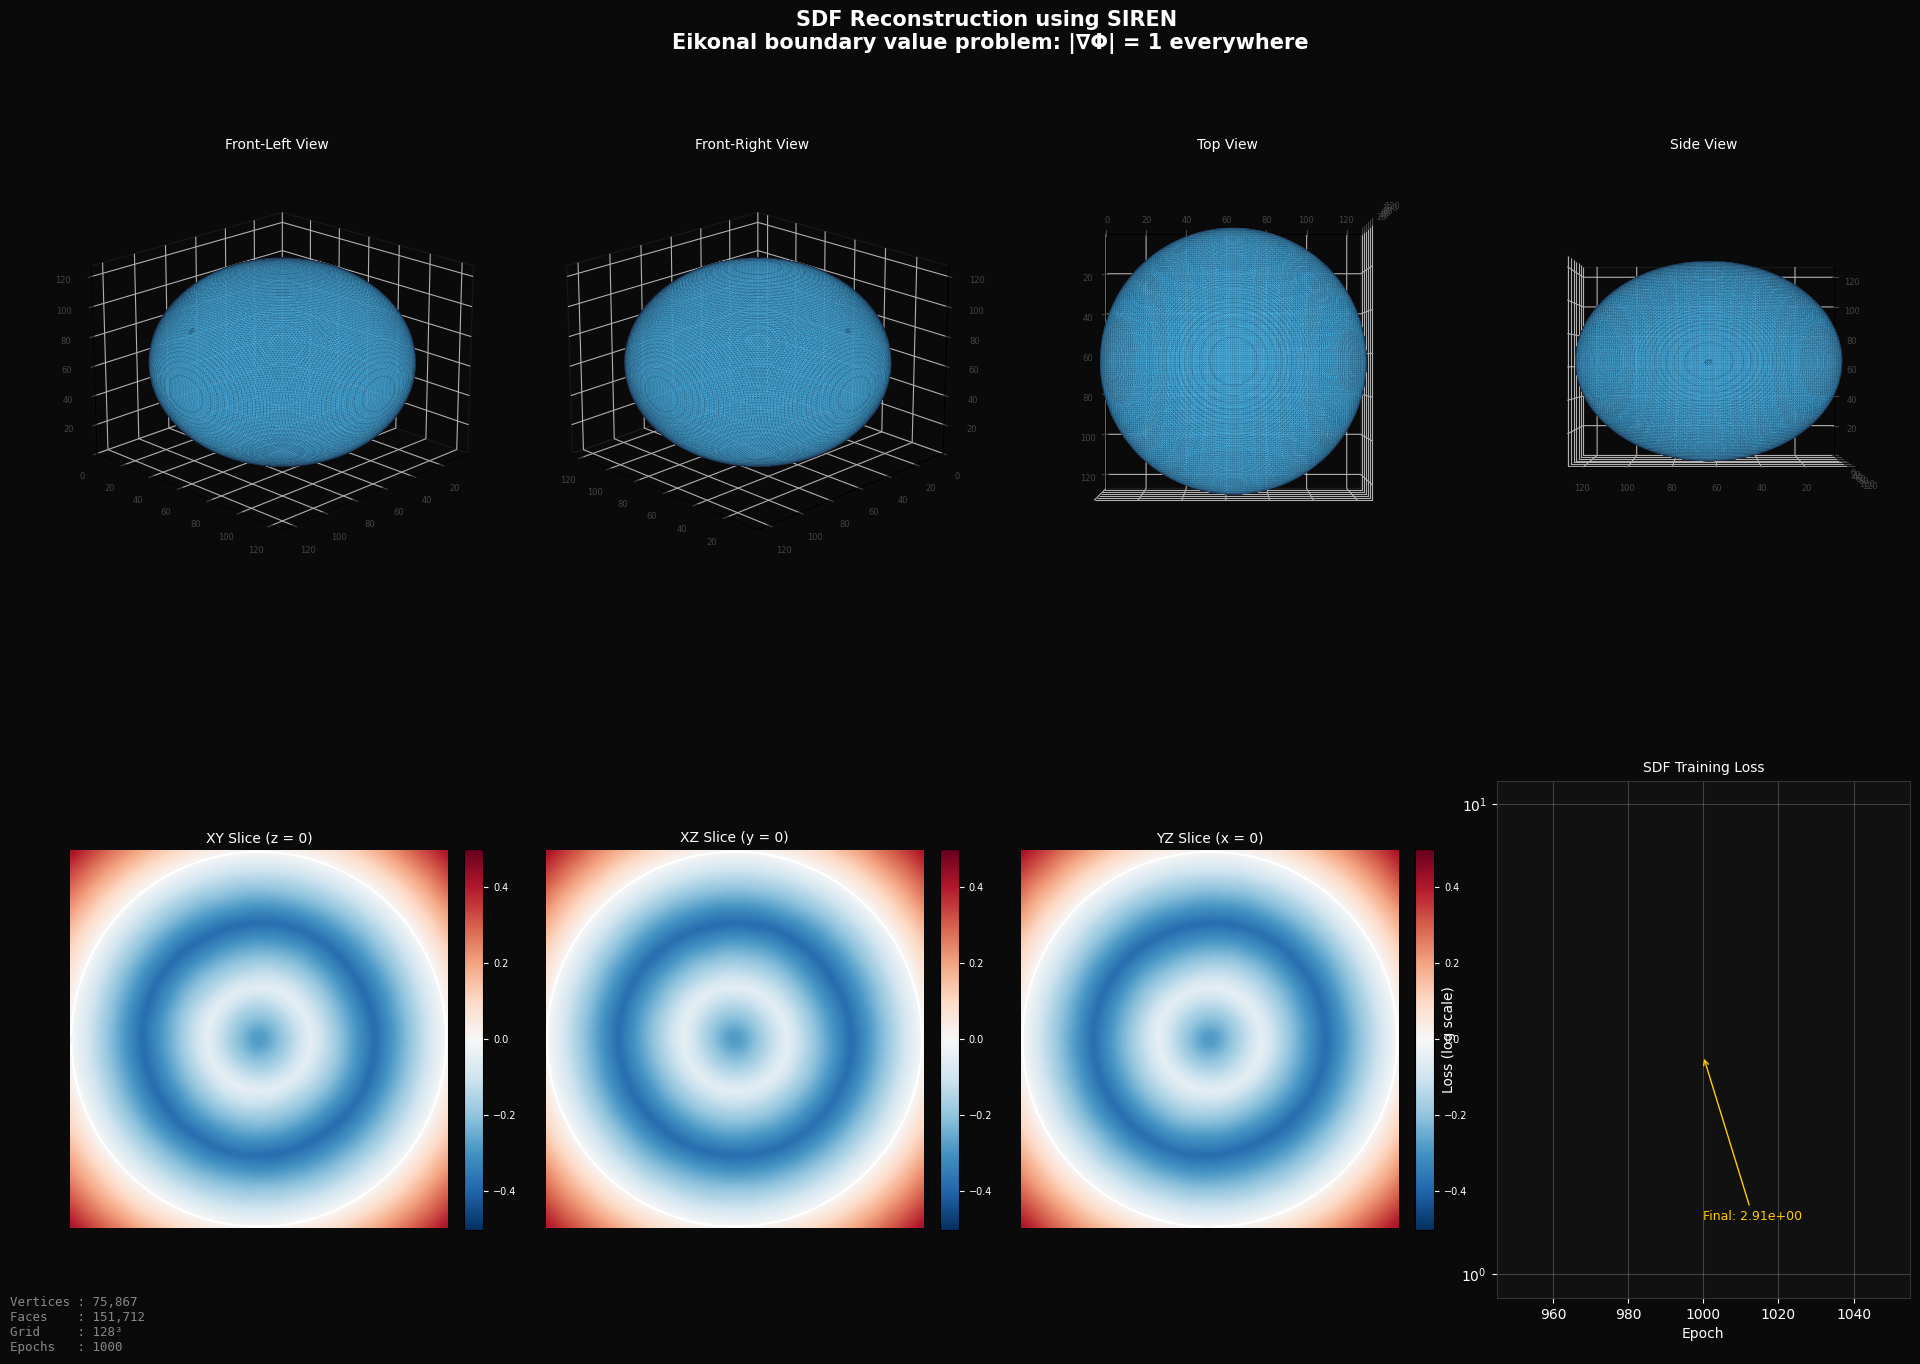

Saved → /content/siren/results/sdf_results.png


In [35]:
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

fig = plt.figure(figsize=(20, 14), facecolor='#0a0a0a')
fig.suptitle(
    'SDF Reconstruction using SIREN \n'
    'Eikonal boundary value problem: |∇Φ| = 1 everywhere',
    fontsize=15, color='white', fontweight='bold', y=0.98
)

gs = gridspec.GridSpec(
    2, 4,
    figure=fig,
    hspace=0.3, wspace=0.15,
    left=0.04, right=0.96,
    top=0.91, bottom=0.06
)

FACE_COLOR  = '#4fc3f7'
EDGE_COLOR  = '#1a1a2e'
BG_COLOR    = '#0a0a0a'

def add_mesh_view(fig, gs_pos, verts, faces, elev, azim, title):
    ax = fig.add_subplot(gs_pos, projection='3d')
    ax.set_facecolor(BG_COLOR)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('#222222')
    ax.yaxis.pane.set_edgecolor('#222222')
    ax.zaxis.pane.set_edgecolor('#222222')
    ax.tick_params(colors='#444444', labelsize=6)

    mesh_coll = Poly3DCollection(
        verts[faces],
        alpha=0.85,
        linewidth=0.05,
        edgecolor=EDGE_COLOR
    )
    mesh_coll.set_facecolor(FACE_COLOR)
    ax.add_collection3d(mesh_coll)

    ax.set_xlim(verts[:,0].min(), verts[:,0].max())
    ax.set_ylim(verts[:,1].min(), verts[:,1].max())
    ax.set_zlim(verts[:,2].min(), verts[:,2].max())
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(title, color='white', fontsize=10, pad=8)
    return ax

# ── ROW 1: 3D views of reconstructed mesh ─────────────────────────────────
add_mesh_view(fig, gs[0,0], verts, faces, elev=20,  azim=45,  title='Front-Left View')
add_mesh_view(fig, gs[0,1], verts, faces, elev=20,  azim=135, title='Front-Right View')
add_mesh_view(fig, gs[0,2], verts, faces, elev=90,  azim=0,   title='Top View')
add_mesh_view(fig, gs[0,3], verts, faces, elev=0,   azim=90,  title='Side View')

# ── ROW 2: Cross-section slices + loss curve ──────────────────────────────
mid = sdf_grid.shape[0] // 2

slices = [
    (sdf_grid[:, :, mid], 'XY Slice (z = 0)'),
    (sdf_grid[:, mid, :], 'XZ Slice (y = 0)'),
    (sdf_grid[mid, :, :], 'YZ Slice (x = 0)'),
]

for col, (sl, title) in enumerate(slices):
    ax = fig.add_subplot(gs[1, col])
    ax.set_facecolor(BG_COLOR)
    im = ax.imshow(
        sl, cmap='RdBu_r', origin='lower',
        interpolation='bicubic',
        vmin=-0.5, vmax=0.5
    )
    # Draw zero contour (the surface)
    ax.contour(sl, levels=[0], colors='white', linewidths=1.5)
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.ax.yaxis.set_tick_params(color='white')
    cb.ax.tick_params(labelcolor='white', labelsize=7)
    ax.set_title(title, color='white', fontsize=10)
    ax.axis('off')

# ── Loss curve ────────────────────────────────────────────────────────────
ax_loss = fig.add_subplot(gs[1, 3])
ax_loss.set_facecolor('#111111')
ax_loss.semilogy(epochs_sdf, losses_sdf,
                 color='#4fc3f7', linewidth=2)
ax_loss.set_xlabel('Epoch',            color='white', fontsize=10)
ax_loss.set_ylabel('Loss (log scale)', color='white', fontsize=10)
ax_loss.set_title('SDF Training Loss', color='white', fontsize=10)
ax_loss.tick_params(colors='white')
ax_loss.spines[:].set_color('#333333')
ax_loss.grid(True, alpha=0.2, color='white')
ax_loss.annotate(
    f'Final: {losses_sdf[-1]:.2e}',
    xy=(epochs_sdf[-1], losses_sdf[-1]),
    xytext=(0.5, 0.15), textcoords='axes fraction',
    color='#ffcc00', fontsize=9,
    arrowprops=dict(arrowstyle='->', color='#ffcc00')
)

# Stats box
stats_text = (
    f'Vertices : {len(verts):,}\n'
    f'Faces    : {len(faces):,}\n'
    f'Grid     : 128³\n'
    f'Epochs   : {epochs_sdf[-1]}'
)
fig.text(
    0.01, 0.02, stats_text,
    color='#888888', fontsize=9,
    fontfamily='monospace',
    verticalalignment='bottom'
)

plt.savefig('/content/siren/results/sdf_results.png',
            dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()
print('Saved → /content/siren/results/sdf_results.png')

---
## Combined Summary Figure

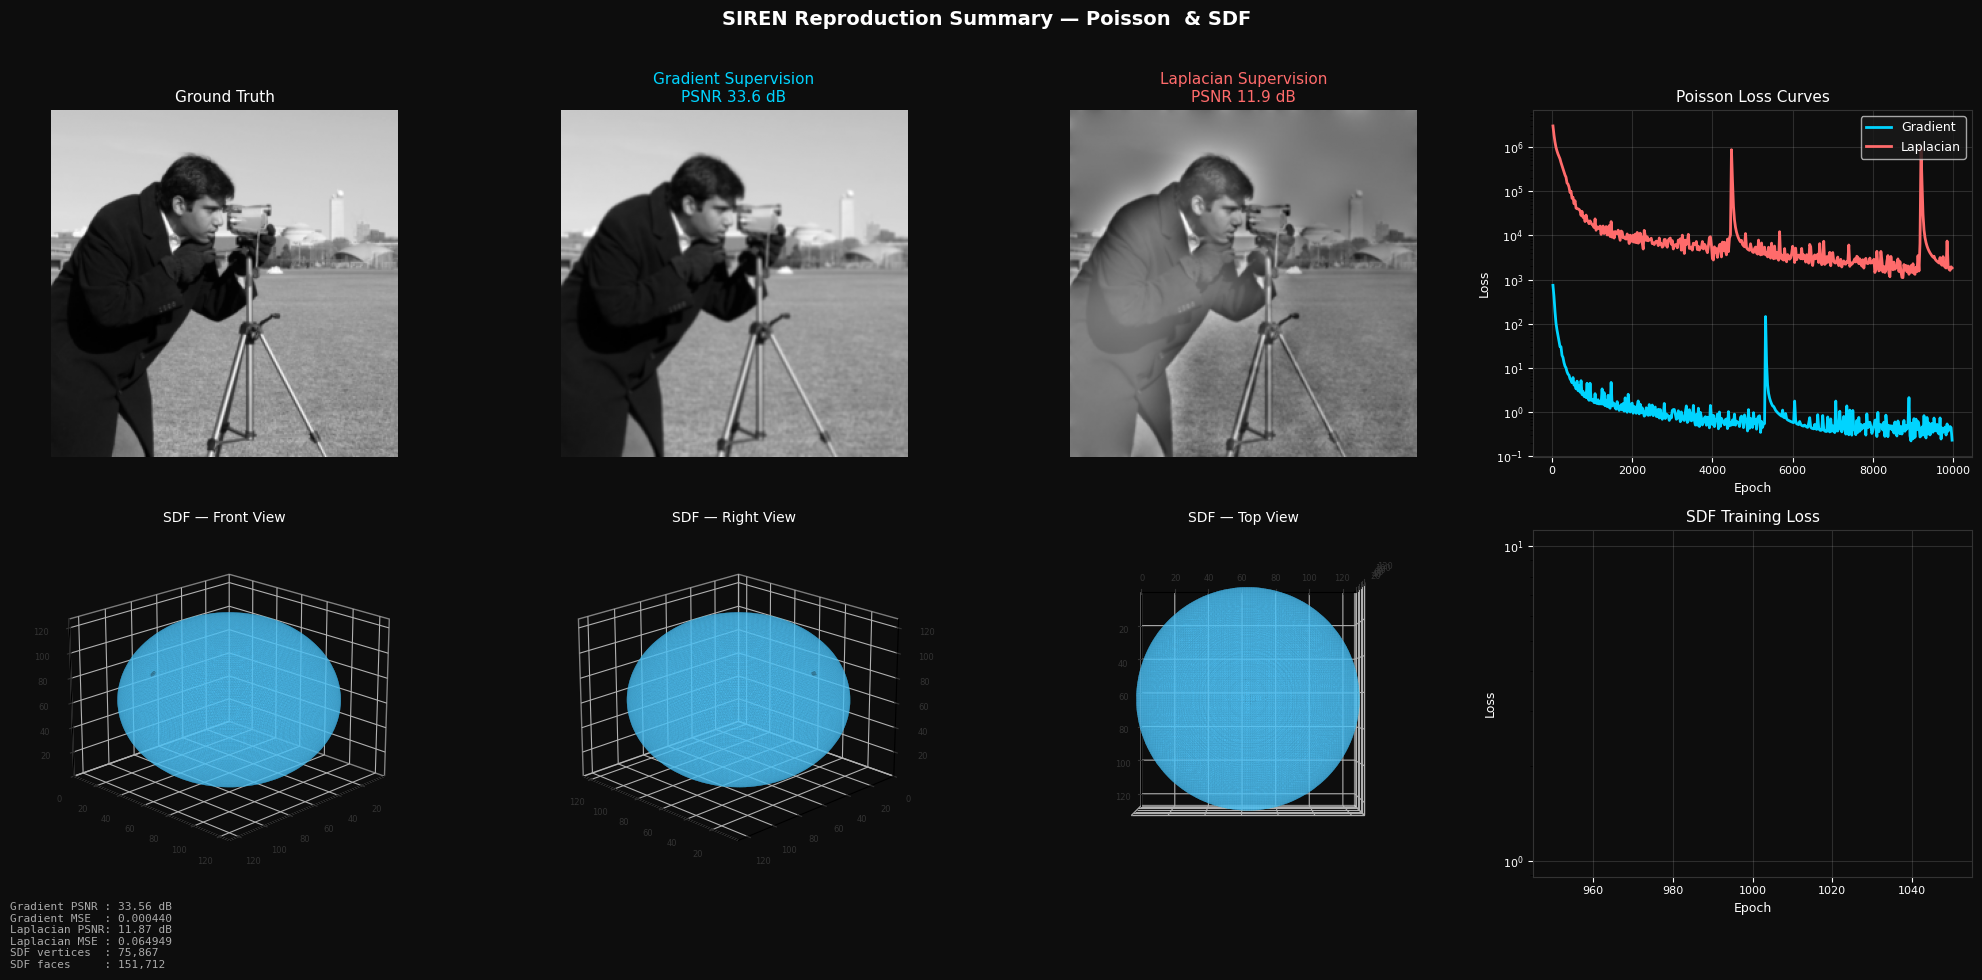

Saved → /content/siren/results/summary.png

All results saved to /content/siren/results/


In [34]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10), facecolor='#0d0d0d')
fig.suptitle(
    'SIREN Reproduction Summary — Poisson  & SDF ',
    fontsize=14, color='white', fontweight='bold'
)

for ax in axes.ravel():
    ax.set_facecolor('#0d0d0d')

# ── Row 1: Poisson ────────────────────────────────────────────────────────
axes[0,0].imshow(normalize(gt_img_g), cmap='gray')
axes[0,0].set_title('Ground Truth', color='white', fontsize=11)
axes[0,0].axis('off')

axes[0,1].imshow(normalize(pred_img_g), cmap='gray')
axes[0,1].set_title(f'Gradient Supervision\nPSNR {psnr_g:.1f} dB', color='#00d4ff', fontsize=11)
axes[0,1].axis('off')

axes[0,2].imshow(normalize(pred_img_l), cmap='gray')
axes[0,2].set_title(f'Laplacian Supervision\nPSNR {psnr_l:.1f} dB', color='#ff6b6b', fontsize=11)
axes[0,2].axis('off')

axes[0,3].semilogy(epochs_g, losses_g, color='#00d4ff', lw=2, label='Gradient')
axes[0,3].semilogy(epochs_l, losses_l, color='#ff6b6b', lw=2, label='Laplacian')
axes[0,3].set_title('Poisson Loss Curves', color='white', fontsize=11)
axes[0,3].tick_params(colors='white', labelsize=8)
axes[0,3].spines[:].set_color('#333333')
axes[0,3].legend(fontsize=9, facecolor='#1a1a1a', labelcolor='white')
axes[0,3].grid(True, alpha=0.2)
axes[0,3].set_xlabel('Epoch', color='white', fontsize=9)
axes[0,3].set_ylabel('Loss',  color='white', fontsize=9)

# ── Row 2: SDF ────────────────────────────────────────────────────────────
views = [(20, 45), (20, 135), (90, 0)]
titles = ['SDF — Front View', 'SDF — Right View', 'SDF — Top View']

for col, ((elev, azim), title) in enumerate(zip(views, titles)):
    ax = axes[1, col]
    # Replace with 3D axes
    ax.remove()
    ax3d = fig.add_subplot(2, 4, 5 + col, projection='3d')
    ax3d.set_facecolor('#0d0d0d')
    ax3d.xaxis.pane.fill = False
    ax3d.yaxis.pane.fill = False
    ax3d.zaxis.pane.fill = False

    mesh_coll = Poly3DCollection(verts[faces], alpha=0.8, linewidth=0.0)
    mesh_coll.set_facecolor('#4fc3f7')
    ax3d.add_collection3d(mesh_coll)
    ax3d.set_xlim(verts[:,0].min(), verts[:,0].max())
    ax3d.set_ylim(verts[:,1].min(), verts[:,1].max())
    ax3d.set_zlim(verts[:,2].min(), verts[:,2].max())
    ax3d.view_init(elev=elev, azim=azim)
    ax3d.set_title(title, color='white', fontsize=10)
    ax3d.tick_params(colors='#333333', labelsize=6)

# SDF loss
axes[1,3].semilogy(epochs_sdf, losses_sdf, color='#4fc3f7', lw=2)
axes[1,3].set_title('SDF Training Loss', color='white', fontsize=11)
axes[1,3].tick_params(colors='white', labelsize=8)
axes[1,3].spines[:].set_color('#333333')
axes[1,3].grid(True, alpha=0.2)
axes[1,3].set_xlabel('Epoch', color='white', fontsize=9)
axes[1,3].set_ylabel('Loss',  color='white', fontsize=9)

# Metrics box
metrics_str = (
    f'Gradient PSNR : {psnr_g:.2f} dB\n'
    f'Gradient MSE  : {mse_g:.6f}\n'
    f'Laplacian PSNR: {psnr_l:.2f} dB\n'
    f'Laplacian MSE : {mse_l:.6f}\n'
    f'SDF vertices  : {len(verts):,}\n'
    f'SDF faces     : {len(faces):,}'
)
fig.text(
    0.01, 0.02, metrics_str,
    color='#aaaaaa', fontsize=8,
    fontfamily='monospace',
    verticalalignment='bottom'
)

plt.tight_layout(rect=[0, 0.06, 1, 0.96])
plt.savefig('/content/siren/results/summary.png',
            dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print('Saved → /content/siren/results/summary.png')
print('\nAll results saved to /content/siren/results/')